## Time Series Logistic Regression and Random Forest Model: Predicting Wildfires in California



This is all the code for generating the Logistic Regression and Random Forest model for our California Wildfires dataset. We tested it on 2023 data to validate the model.

In [3]:
#importing data

import pandas as pd
df = pd.read_csv(
    "CA_Weather_Fire_Dataset_1984-2025.csv",
    engine="python",
    on_bad_lines="warn"
)
df['DATE'] = pd.to_datetime(df['DATE'])

df

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700000,1
1,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145000,2
2,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220000,3
3,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090000,4
4,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14983,2025-01-08,0.0,73.0,53.0,10.51,False,2025,20.0,0.143973,1,Winter,0.0,6.485714,8
14984,2025-01-09,0.0,68.0,46.0,4.92,False,2025,22.0,0.072353,1,Winter,0.0,6.550000,9
14985,2025-01-10,0.0,70.0,46.0,3.58,False,2025,24.0,0.051143,1,Winter,0.0,6.327143,10
14986,2025-01-11,0.0,66.0,46.0,NaN,False,2025,20.0,NaN,1,Winter,0.0,6.561667,11


In [4]:
#Cleaning data

#removing extra date columns
df = df.drop(columns=['MONTH','DAY_OF_YEAR'])

#making fire variable binary
df['FIRE_START_DAY'] = df['FIRE_START_DAY'].astype(int)

#removing rows with null values
df=df.dropna()

#finalized df to csv file
df.to_csv("cleaned_df.csv", index=False)



In [5]:
#identifying target variables

y = df['FIRE_START_DAY']

#features included in model
X = df[['PRECIPITATION','MAX_TEMP','MIN_TEMP','AVG_WIND_SPEED',
        'TEMP_RANGE','WIND_TEMP_RATIO',
        'LAGGED_PRECIPITATION','LAGGED_AVG_WIND_SPEED']]


In [6]:
#creating training and test sets for logistic regression

train = df[df['YEAR'] <= 2022]
test = df[df['YEAR'] == 2023]

X_train = train[X.columns]
y_train = train['FIRE_START_DAY']

X_test = test[X.columns]
y_test = test['FIRE_START_DAY']

#using sklearn package to complete logistic regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000,class_weight='balanced')

log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)

#displaying results
print("Accuracy:", accuracy_score(y_test, pred_log))
print(classification_report(y_test, pred_log))

Accuracy: 0.7561643835616438
              precision    recall  f1-score   support

           0       0.82      0.77      0.79       224
           1       0.67      0.74      0.70       141

    accuracy                           0.76       365
   macro avg       0.74      0.75      0.75       365
weighted avg       0.76      0.76      0.76       365



In [7]:
#packages needed for random forest model generation

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

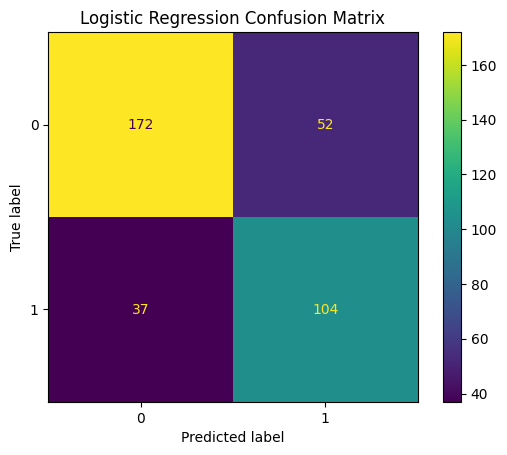

In [8]:
#confusion matrix demonstrates how often the model was correct in predicting fire versus non-fire days

cm = confusion_matrix(y_test, pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [9]:
#5 fold cross validation to confirm our results are accurate accross different samples

cv_scores = cross_val_score(log_model, X_train, y_train, cv=5, scoring='recall')

print("Cross Validation Recall Scores:", cv_scores)
print("Average Recall:", np.mean(cv_scores))

Cross Validation Recall Scores: [0.86645963 0.83022774 0.76190476 0.76293996 0.77018634]
Average Recall: 0.798343685300207


In [10]:
#Creating the random forest model

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

In [11]:
#results from the random forest model

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print("Random Forest Precision:", precision_score(y_test, pred_rf))
print("Random Forest Recall:", recall_score(y_test, pred_rf))
print("Random Forest F1:", f1_score(y_test, pred_rf))

Random Forest Accuracy: 0.7671232876712328
Random Forest Precision: 0.7
Random Forest Recall: 0.6950354609929078
Random Forest F1: 0.697508896797153


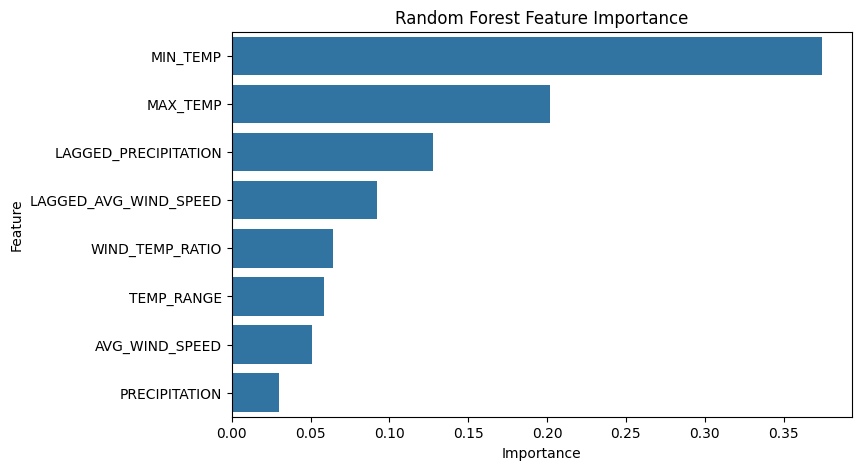

In [12]:
#feature importance to determine what factors are most important in predicting wildfires
importances = rf_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Random Forest Feature Importance")
plt.show()

In [13]:
print("Actual fires in 2023:", y_test.sum())
print("Predicted fires (Logistic):", pred_log.sum())
print("Predicted fires (Random Forest):", pred_rf.sum())

Actual fires in 2023: 141
Predicted fires (Logistic): 156
Predicted fires (Random Forest): 140


In [14]:
best_model = rf_model  # or log_model depending on results

future_data = df[df['YEAR'] == 2024][X.columns]

future_predictions = best_model.predict(future_data)

print(future_predictions[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [15]:
from sklearn.metrics import roc_auc_score

probs = log_model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, probs)

print("ROC-AUC:", roc)

ROC-AUC: 0.8152545592705167


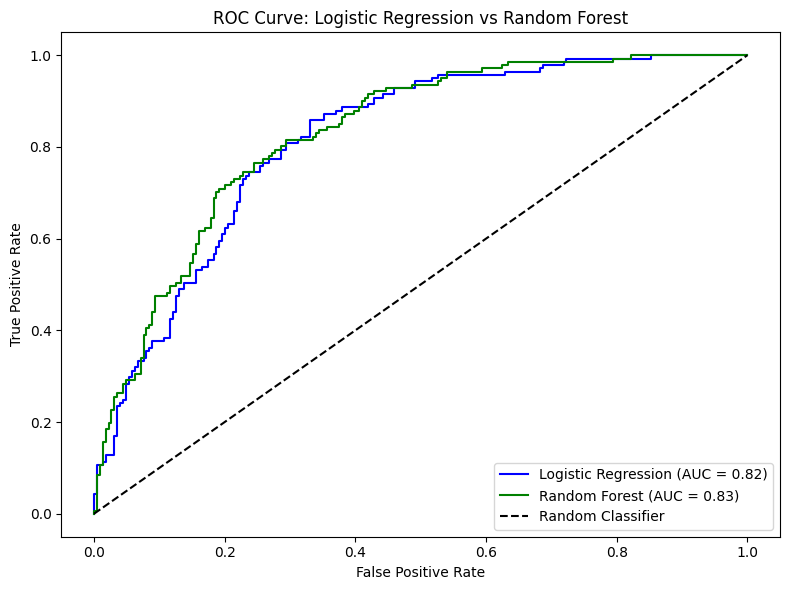

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for both models
log_probs = log_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC curves
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# Compute AUC scores
log_auc = roc_auc_score(y_test, log_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(log_fpr, log_tpr, label=f'Logistic Regression (AUC = {log_auc:.2f})', color='blue')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression vs Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()